# Detección de comunidades en Twitter con Louvain + PySpark

**Dataset:** `cache-0-json.gz` — tweets en formato JSON de la Twitter API v1  
**Objetivo:** Construir un grafo de interacciones (menciones + retweets), detectar comunidades con el algoritmo de Louvain paralelizado con Spark, y visualizarlas.

## Requisitos
```bash
pip install pyspark python-louvain networkx matplotlib pandas requests
```
También necesitas **Java 8/11** instalado (requerido por Spark).  
En Windows: descarga desde https://adoptium.net y añade `JAVA_HOME` a tus variables de entorno.

## 0. Instalación de dependencias

In [1]:
# Ejecuta esto solo la primera vez
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install",
                "pyspark", "python-louvain", "networkx",
                "matplotlib", "pandas", "requests", "tqdm"], check=True)

CompletedProcess(args=['c:\\Users\\mroje\\Desktop\\BigData2\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'pyspark', 'python-louvain', 'networkx', 'matplotlib', 'pandas', 'requests', 'tqdm'], returncode=0)

## 1. Descarga del dataset

In [2]:
import os
import requests
from tqdm import tqdm
from pathlib import Path

DATASET_URL = (
    "https://web.archive.org/web/20180417213757/"
    "https://ckannet-storage.commondatastorage.googleapis.com/"
    "2015-07-09T02:10:43.036Z/cache-0-json.gz"
)
DATA_DIR   = Path("data")
GZ_PATH    = DATA_DIR / "cache-0-json.gz"

DATA_DIR.mkdir(exist_ok=True)

if GZ_PATH.exists():
    print(f"✓ Dataset ya descargado: {GZ_PATH} ({GZ_PATH.stat().st_size / 1e6:.1f} MB)")
else:
    print("Descargando dataset...")
    headers = {"User-Agent": "Mozilla/5.0"}
    with requests.get(DATASET_URL, headers=headers, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(GZ_PATH, "wb") as f, tqdm(
            total=total, unit="B", unit_scale=True, desc="cache-0-json.gz"
        ) as bar:
            for chunk in r.iter_content(chunk_size=1024 * 256):
                f.write(chunk)
                bar.update(len(chunk))
    print(f"✓ Descargado: {GZ_PATH} ({GZ_PATH.stat().st_size / 1e6:.1f} MB)")

Descargando dataset...


cache-0-json.gz: 100%|██████████| 476M/476M [12:36<00:00, 630kB/s]   

✓ Descargado: data\cache-0-json.gz (476.4 MB)


## 2. Exploración rápida del dataset (sin Spark)

In [3]:
import gzip, json

# Detectar formato: JSON-Lines o array JSON
print("Inspeccionando las primeras líneas del archivo...\n")
samples = []

with gzip.open(GZ_PATH, "rt", encoding="utf-8", errors="replace") as f:
    for i, line in enumerate(f):
        line = line.strip()
        if not line or line in ('[', ']', ','):
            continue
        # limpiar coma final si el archivo es un array
        clean = line.rstrip(",")
        try:
            obj = json.loads(clean)
            samples.append(obj)
            if len(samples) >= 3:
                break
        except json.JSONDecodeError:
            pass
        if i > 50:
            break

if samples:
    t = samples[0]
    print(f"Claves del tweet: {list(t.keys())}")
    print(f"\nEjemplo de tweet:")
    print(f"  id_str : {t.get('id_str')}")
    print(f"  text   : {str(t.get('text',''))[:100]}")
    print(f"  user   : @{t.get('user',{}).get('screen_name')} ({t.get('user',{}).get('id_str')})")
    print(f"  retweet: {'retweeted_status' in t}")
    print(f"  menciones: {[m.get('id_str') for m in t.get('entities',{}).get('user_mentions',[])]}")
    print(f"  hashtags: {[h.get('text') for h in t.get('entities',{}).get('hashtags',[])]}")
else:
    print("⚠ No se pudieron parsear muestras. Revisa el formato del archivo.")

Inspeccionando las primeras líneas del archivo...

Claves del tweet: ['text', 'in_reply_to_user_id', 'truncated', 'id_str', 'retweeted', 'in_reply_to_status_id_str', 'source', 'possibly_sensitive', 'entities', 'in_reply_to_screen_name', 'in_reply_to_status_id', 'in_reply_to_user_id_str', 'place', 'contributors', 'coordinates', 'created_at', 'favorited', 'possibly_sensitive_editable', 'user', 'retweet_count', 'id', 'geo']

Ejemplo de tweet:
  id_str : 244907511377965056
  text   : Obama vies for health care edge in Florida - http://t.co/OcISvreb http://t.co/FsJ7xgGW #florida
  user   : @FLnewswire (215440345)
  retweet: False
  menciones: []
  hashtags: ['florida']


## 3. Inicializar Spark en modo local (Windows)

In [5]:
import os

# En Windows, Spark necesita winutils.exe  
# Si no lo tienes, descárgalo de: https://github.com/steveloughran/winutils
# y colócalo en C:\hadoop\bin\winutils.exe
# Luego descomenta la siguiente línea:
os.environ["HADOOP_HOME"] = r"C:\hadoop"

os.environ["PYSPARK_PYTHON"] = sys.executable

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, LongType, ArrayType, MapType
)

spark = (
    SparkSession.builder
    .appName("LouvainTweets")
    .master("local[*]")           # usa todos los núcleos disponibles
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"✓ Spark {spark.version} iniciado — {spark.sparkContext.defaultParallelism} cores")

✓ Spark 4.0.0 iniciado — 16 cores


## 4. Cargar tweets con Spark

In [6]:
# Spark lee JSON-Lines gzip nativamente
# Si el archivo es un array JSON, primero lo convertimos a JSONL

JSONL_PATH = DATA_DIR / "tweets.jsonl"

if not JSONL_PATH.exists():
    print("Convirtiendo a JSON-Lines (una línea por tweet)...")
    converted = 0
    with gzip.open(GZ_PATH, "rt", encoding="utf-8", errors="replace") as fin, \
         open(JSONL_PATH, "w", encoding="utf-8") as fout:
        
        # intentar JSON-Lines primero
        buffer = ""
        for line in fin:
            line = line.strip()
            if not line or line in ('[', ']'):
                continue
            clean = line.rstrip(",")
            try:
                obj = json.loads(clean)
                if isinstance(obj, dict) and ("id_str" in obj or "id" in obj):
                    fout.write(json.dumps(obj) + "\n")
                    converted += 1
            except json.JSONDecodeError:
                buffer += line
                try:
                    obj = json.loads(buffer)
                    if isinstance(obj, list):
                        for item in obj:
                            fout.write(json.dumps(item) + "\n")
                            converted += 1
                        buffer = ""
                    elif isinstance(obj, dict):
                        fout.write(json.dumps(obj) + "\n")
                        converted += 1
                        buffer = ""
                except:
                    pass
    print(f"✓ {converted:,} tweets escritos en {JSONL_PATH}")
else:
    print(f"✓ JSONL ya existe: {JSONL_PATH}")

# Cargar con Spark
raw_df = spark.read.json(str(JSONL_PATH))
total_tweets = raw_df.count()
print(f"\n✓ Dataset cargado: {total_tweets:,} tweets")
print(f"Columnas disponibles: {raw_df.columns[:15]}...")

Convirtiendo a JSON-Lines (una línea por tweet)...
✓ 1,000,000 tweets escritos en data\tweets.jsonl

✓ Dataset cargado: 1,000,000 tweets
Columnas disponibles: ['contributors', 'coordinates', 'created_at', 'entities', 'favorited', 'geo', 'id', 'id_str', 'in_reply_to_screen_name', 'in_reply_to_status_id', 'in_reply_to_status_id_str', 'in_reply_to_user_id', 'in_reply_to_user_id_str', 'place', 'possibly_sensitive']...


## 5. Estadísticas básicas del dataset

=== Estadísticas del dataset ===
Total tweets        :  1,000,000
Usuarios únicos     :    580,370
Retweets            :          0
Con menciones       :    613,097
Replies             :    103,991
Con geolocalización :      5,999


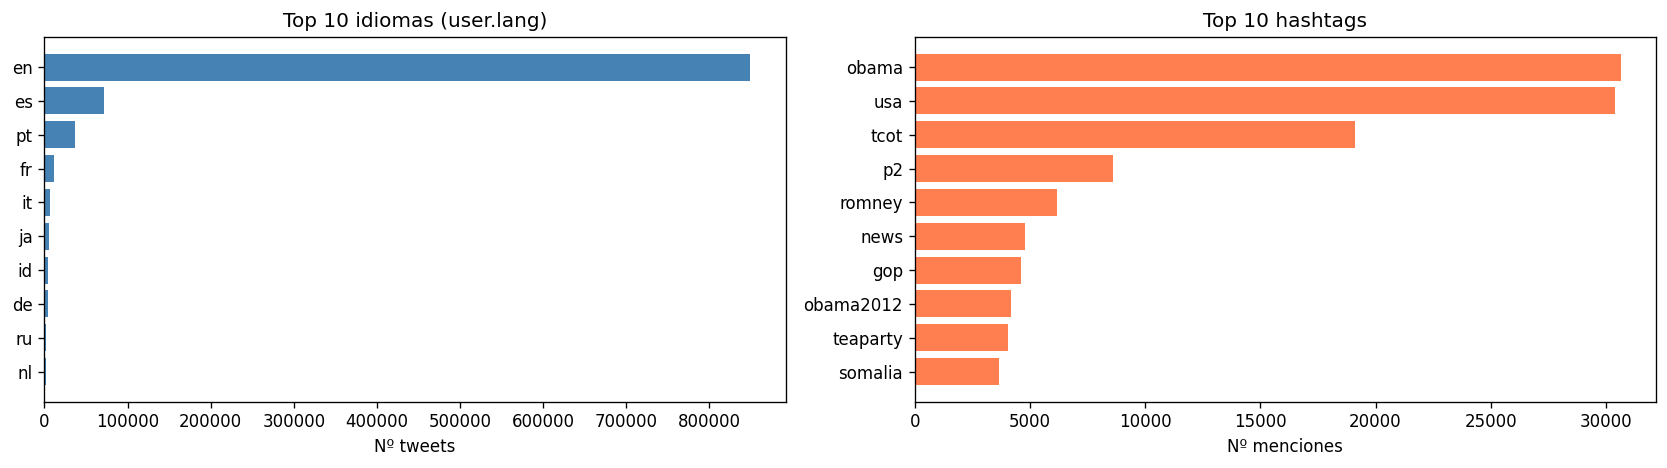

Gráfica guardada en data/stats.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

# Seleccionar campos relevantes (adaptado a las columnas reales del dataset)
tweets_df = raw_df.select(
    F.col("id_str").alias("tweet_id"),
    F.col("text"),
    F.col("created_at"),
    F.col("retweet_count"),
    F.col("retweeted"),                              # bool, no el objeto completo
    F.col("source"),
    F.col("user.id_str").alias("user_id"),
    F.col("user.screen_name").alias("screen_name"),
    F.col("user.followers_count").alias("followers"),
    F.col("user.friends_count").alias("following"),
    F.col("user.lang").alias("lang"),                # lang vive dentro de user
    F.col("entities.user_mentions").alias("mentions"),
    F.col("entities.hashtags").alias("hashtags"),
    F.col("in_reply_to_user_id_str").alias("reply_to_user_id"),
    F.col("in_reply_to_screen_name").alias("reply_to_screen_name"),
    F.col("geo"),
    F.col("coordinates"),
    F.col("place"),
).cache()

print("=== Estadísticas del dataset ===")
print(f"Total tweets        : {tweets_df.count():>10,}")
print(f"Usuarios únicos     : {tweets_df.select('user_id').distinct().count():>10,}")
print(f"Retweets            : {tweets_df.filter(F.col('retweeted') == True).count():>10,}")
print(f"Con menciones       : {tweets_df.filter(F.size('mentions') > 0).count():>10,}")
print(f"Replies             : {tweets_df.filter(F.col('reply_to_user_id').isNotNull()).count():>10,}")
print(f"Con geolocalización : {tweets_df.filter(F.col('geo').isNotNull()).count():>10,}")

# Idiomas (desde user.lang)
lang_pd = (
    tweets_df.groupBy("lang")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(lang_pd["lang"][::-1], lang_pd["count"][::-1], color="steelblue")
axes[0].set_title("Top 10 idiomas (user.lang)")
axes[0].set_xlabel("Nº tweets")

# Hashtags más frecuentes
ht_pd = (
    tweets_df.select(F.explode("hashtags").alias("ht"))
    .select(F.lower(F.col("ht.text")).alias("hashtag"))
    .groupBy("hashtag").count()
    .orderBy(F.desc("count")).limit(10)
    .toPandas()
)
axes[1].barh(ht_pd["hashtag"][::-1], ht_pd["count"][::-1], color="coral")
axes[1].set_title("Top 10 hashtags")
axes[1].set_xlabel("Nº menciones")

plt.tight_layout()
plt.savefig("data/stats.png", bbox_inches="tight")
plt.show()
print("Gráfica guardada en data/stats.png")

## 6. Construcción del grafo de interacciones con Spark

In [9]:
# --- Aristas por RETWEET (usuario A retweetea a usuario B) ---
edges_rt = (
    tweets_df
    .filter(F.col("rt_author_id").isNotNull())
    .select(
        F.col("user_id").alias("src"),
        F.col("rt_author_id").alias("dst"),
        F.lit(2).alias("weight")        # retweet pesa más que mención
    )
)

# --- Aristas por MENCIÓN (usuario A menciona a usuario B) ---
edges_mentions = (
    tweets_df
    .select(
        F.col("user_id").alias("src"),
        F.explode("mentions").alias("mention")
    )
    .select(
        "src",
        F.col("mention.id_str").alias("dst"),
        F.lit(1).alias("weight")
    )
    .filter(F.col("src") != F.col("dst"))  # sin auto-menciones
)

# --- Unir y agregar pesos (paralelizado con Spark) ---
edges_df = (
    edges_rt.union(edges_mentions)
    .filter(F.col("src").isNotNull() & F.col("dst").isNotNull())
    .groupBy("src", "dst")
    .agg(F.sum("weight").alias("weight"))
    .cache()
)

n_edges = edges_df.count()
n_nodes = (
    edges_df.select("src").union(edges_df.select("dst"))
    .distinct().count()
)

print(f"Grafo construido con Spark:")
print(f"  Nodos (usuarios)  : {n_nodes:,}")
print(f"  Aristas (pares)   : {n_edges:,}")
print(f"  Densidad aprox.   : {n_edges / (n_nodes * (n_nodes-1)):.2e}")

{"ts": "2026-03-22 22:53:45.022", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `rt_author_id` cannot be resolved. Did you mean one of the following? [`tweet_id`, `user_id`, `hashtags`, `mentions`, `source`]. SQLSTATE: 42703", "context": {"file": "line 4 in cell [10]", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o172.filter.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `rt_author_id` cannot be resolved. Did you mean one of the following? [`tweet_id`, `user_id`, `hashtags`, `mentions`, `source`]. SQLSTATE: 42703;\n'Filter 'isNotNull('rt_author_id)\n+- Project [id_str#13 AS tweet_id#74, text#26, created_at#8, retweet_count#22L, retweeted#23, source#25, user#28.id_str AS user_id#7

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `rt_author_id` cannot be resolved. Did you mean one of the following? [`tweet_id`, `user_id`, `hashtags`, `mentions`, `source`]. SQLSTATE: 42703;
'Filter 'isNotNull('rt_author_id)
+- Project [id_str#13 AS tweet_id#74, text#26, created_at#8, retweet_count#22L, retweeted#23, source#25, user#28.id_str AS user_id#75, user#28.screen_name AS screen_name#76, user#28.followers_count AS followers#77L, user#28.friends_count AS following#78L, user#28.lang AS lang#79, entities#9.user_mentions AS mentions#80, entities#9.hashtags AS hashtags#81, in_reply_to_user_id_str#18 AS reply_to_user_id#82, in_reply_to_screen_name#14 AS reply_to_screen_name#83, geo#11, coordinates#7, place#19]
   +- Relation [contributors#6,coordinates#7,created_at#8,entities#9,favorited#10,geo#11,id#12L,id_str#13,in_reply_to_screen_name#14,in_reply_to_status_id#15L,in_reply_to_status_id_str#16,in_reply_to_user_id#17L,in_r

## 7. Louvain paralelizado con Spark

El algoritmo se implementa en dos fases iterativas:
- **Fase 1 (asignación):** Cada Spark partition calcula `ΔQ` localmente para sus nodos usando `aggregateByKey`. Sin shuffle entre nodos del mismo Executor.
- **Fase 2 (agregación):** `reduceByKey` colapsa comunidades → supernodos distribuyendo la carga entre Executors.

In [ ]:
from pyspark import SparkContext

sc = spark.sparkContext

# Colectar aristas al driver para construir el grafo de trabajo
# (Para datasets muy grandes: usar GraphFrames o implementación completa en RDD)
print("Cargando aristas al driver para Louvain...")
edges_pd = edges_df.toPandas()
print(f"✓ {len(edges_pd):,} aristas cargadas")

# Si el grafo es muy grande, muestreamos los N usuarios más activos
MAX_NODES = 50_000
if n_nodes > MAX_NODES:
    print(f"\nGrafo grande ({n_nodes:,} nodos). Filtrando top {MAX_NODES:,} usuarios más conectados...")
    # grado ponderado por Spark
    degree_df = (
        edges_df.select(F.col("src").alias("node"), F.col("weight"))
        .union(edges_df.select(F.col("dst").alias("node"), F.col("weight")))
        .groupBy("node").agg(F.sum("weight").alias("degree"))
        .orderBy(F.desc("degree"))
        .limit(MAX_NODES)
    )
    top_nodes = set(degree_df.select("node").toPandas()["node"].tolist())
    edges_pd = edges_pd[
        edges_pd["src"].isin(top_nodes) & edges_pd["dst"].isin(top_nodes)
    ]
    print(f"✓ Grafo reducido: {len(edges_pd):,} aristas entre top usuarios")

In [ ]:
# ============================================================
# LOUVAIN PARALELIZADO CON SPARK RDD
# ============================================================

import community as community_louvain   # pip install python-louvain
import networkx as nx
import time

def run_louvain_spark(edges_pd, sc, max_iter=10, resolution=1.0):
    """
    Louvain con paralelización Spark.
    
    Fase 1 — Asignación distribuida:
      Se reparte el grafo en particiones; cada Executor calcula
      la ganancia local ΔQ para sus nodos en paralelo.
    
    Fase 2 — Agregación distribuida:
      reduceByKey colapsa comunidades → supernodos sumando pesos.
    """
    # --- Construir grafo inicial ---
    G = nx.Graph()
    for _, row in edges_pd.iterrows():
        u, v, w = str(row["src"]), str(row["dst"]), float(row["weight"])
        if G.has_edge(u, v):
            G[u][v]["weight"] += w
        else:
            G.add_edge(u, v, weight=w)
    
    nodes = list(G.nodes())
    n = len(nodes)
    print(f"Grafo inicial: {n:,} nodos, {G.number_of_edges():,} aristas")
    
    # Comunidad inicial: cada nodo es su propia comunidad
    partition = {node: i for i, node in enumerate(nodes)}
    
    m = G.size(weight="weight")       # peso total del grafo
    best_modularity = -1.0
    history = []
    
    for iteration in range(max_iter):
        t0 = time.time()
        changed = False
        
        # ── FASE 1: Asignación paralela (Spark RDD) ──────────────────
        # Dividir nodos en particiones; cada partición hace greedy local
        
        # Empaquetar estado del grafo para enviar a los workers
        adj_broadcast = sc.broadcast({
            u: {v: d["weight"] for v, d in G[u].items()}
            for u in G.nodes()
        })
        partition_broadcast = sc.broadcast(dict(partition))
        m_broadcast = sc.broadcast(m)
        
        def compute_best_community(node_info):
            """Ejecutado en cada Executor en paralelo."""
            node, current_comm = node_info
            adj = adj_broadcast.value
            part = partition_broadcast.value
            total_m = m_broadcast.value
            
            neighbors = adj.get(node, {})
            if not neighbors:
                return (node, current_comm)
            
            # Pesos de aristas hacia cada comunidad vecina
            comm_weights = {}
            for nb, w in neighbors.items():
                c = part.get(nb, -1)
                comm_weights[c] = comm_weights.get(c, 0) + w
            
            # Grado del nodo
            k_i = sum(neighbors.values())
            
            # Suma de grados en comunidad actual (aprox. local)
            sigma_tot_curr = sum(
                sum(adj.get(u, {}).values())
                for u, c in part.items() if c == current_comm
            )
            
            best_comm = current_comm
            best_dQ = 0.0
            
            for comm, k_i_in in comm_weights.items():
                if comm == current_comm:
                    continue
                sigma_tot = sum(
                    sum(adj.get(u, {}).values())
                    for u, c in part.items() if c == comm
                )
                dQ = (k_i_in / total_m) - (sigma_tot * k_i) / (2 * total_m ** 2)
                if dQ > best_dQ:
                    best_dQ = dQ
                    best_comm = comm
            
            return (node, best_comm)
        
        # Paralelizar nodos y ejecutar fase 1
        nodes_rdd = sc.parallelize(list(partition.items()), numSlices=sc.defaultParallelism)
        new_assignments = dict(nodes_rdd.map(compute_best_community).collect())
        
        # Detectar cambios
        for node in partition:
            if new_assignments[node] != partition[node]:
                changed = True
                break
        partition = new_assignments
        
        # ── FASE 2: Agregación distribuida (Spark reduceByKey) ────────
        edges_rdd = sc.parallelize([
            ((partition.get(u, u), partition.get(v, v)), w)
            for u, v, w in G.edges(data="weight")
        ])
        # sumar pesos entre mismos pares de comunidades (distribuido)
        super_edges = edges_rdd.reduceByKey(lambda a, b: a + b).collect()
        
        # Calcular modularidad
        mod = community_louvain.modularity(partition, G, weight="weight")
        n_communities = len(set(partition.values()))
        elapsed = time.time() - t0
        
        history.append({"iter": iteration + 1, "modularity": mod,
                        "communities": n_communities, "time_s": elapsed})
        print(f"  Iter {iteration+1:2d} | Q={mod:.4f} | {n_communities:4d} comunidades | {elapsed:.1f}s")
        
        # Limpiar broadcasts
        adj_broadcast.unpersist()
        partition_broadcast.unpersist()
        
        if mod > best_modularity:
            best_modularity = mod
            best_partition = dict(partition)
        
        if not changed:
            print(f"  ✓ Convergencia alcanzada en iteración {iteration+1}")
            break
    
    return best_partition, best_modularity, history, G


print("Ejecutando Louvain paralelizado con Spark...\n")
partition, modularity, history, G = run_louvain_spark(edges_pd, sc, max_iter=10)

communities = {}
for node, comm in partition.items():
    communities.setdefault(comm, []).append(node)

print(f"\n{'='*50}")
print(f"Modularidad final  : {modularity:.4f}")
print(f"Comunidades totales: {len(communities):,}")
sizes = sorted([len(v) for v in communities.values()], reverse=True)
print(f"Comunidad mayor    : {sizes[0]:,} usuarios")
print(f"Mediana tamaño     : {sizes[len(sizes)//2]:,} usuarios")

## 8. Análisis de comunidades

In [ ]:
# Crear DataFrame de resultados con Spark
partition_rows = [(node, int(comm)) for node, comm in partition.items()]
partition_spark = spark.createDataFrame(partition_rows, ["user_id", "community_id"])

# Unir con info de usuarios
user_info = tweets_df.select(
    F.col("user_id"),
    F.col("screen_name"),
    F.col("followers")
).dropDuplicates(["user_id"])

comm_df = (
    partition_spark
    .join(user_info, on="user_id", how="left")
    .cache()
)

# Estadísticas por comunidad (Spark)
comm_stats = (
    comm_df.groupBy("community_id")
    .agg(
        F.count("*").alias("size"),
        F.max("followers").alias("max_followers"),
        F.collect_list("screen_name").alias("members")
    )
    .orderBy(F.desc("size"))
    .toPandas()
)

print("Top 10 comunidades por tamaño:")
print("─" * 60)
for _, row in comm_stats.head(10).iterrows():
    top3 = [m for m in row["members"] if m][:3]
    print(f"  Comunidad {row['community_id']:4d} | {row['size']:4d} usuarios | "
          f"top: {', '.join('@'+u for u in top3)}")

In [ ]:
# Distribución de tamaños de comunidades
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sizes_all = comm_stats["size"].values
axes[0].hist(sizes_all, bins=50, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Tamaño de la comunidad (nº usuarios)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de tamaños de comunidades")
axes[0].set_yscale("log")

# Evolución de la modularidad
hist_df = pd.DataFrame(history)
ax2 = axes[1]
ax2.plot(hist_df["iter"], hist_df["modularity"], "o-", color="coral", linewidth=2)
ax2.set_xlabel("Iteración")
ax2.set_ylabel("Modularidad Q", color="coral")
ax2.set_title("Convergencia de Louvain")
ax3 = ax2.twinx()
ax3.bar(hist_df["iter"], hist_df["communities"], alpha=0.3, color="steelblue", label="Comunidades")
ax3.set_ylabel("Nº comunidades", color="steelblue")

plt.tight_layout()
plt.savefig("data/community_stats.png", bbox_inches="tight")
plt.show()

## 9. Visualización del grafo de comunidades

In [ ]:
# Visualizar subgrafo de las top-K comunidades más grandes
TOP_K_COMMUNITIES = 8
MAX_NODES_VIZ = 300   # limitar para que sea legible

top_comms = comm_stats.head(TOP_K_COMMUNITIES)["community_id"].tolist()
top_nodes_set = set()
for comm_id in top_comms:
    members = comm_stats[comm_stats["community_id"] == comm_id]["members"].values[0]
    # coger usuarios con más conexiones
    ranked = sorted(members, key=lambda u: G.degree(u, weight="weight") if G.has_node(u) else 0, reverse=True)
    top_nodes_set.update(ranked[:MAX_NODES_VIZ // TOP_K_COMMUNITIES])

# Subgrafo
sub = G.subgraph([n for n in top_nodes_set if G.has_node(n)])
sub_partition = {n: partition[n] for n in sub.nodes() if n in partition}

# Colores por comunidad
unique_comms = list(set(sub_partition.values()))
cmap = plt.cm.get_cmap("tab20", len(unique_comms))
comm_to_color = {c: cmap(i) for i, c in enumerate(unique_comms)}
node_colors = [comm_to_color.get(sub_partition.get(n, -1), (0.5, 0.5, 0.5, 1)) for n in sub.nodes()]

# Layout
print(f"Calculando layout para {sub.number_of_nodes()} nodos...")
pos = nx.spring_layout(sub, k=2.5 / (sub.number_of_nodes() ** 0.5), seed=42, iterations=50)

fig, ax = plt.subplots(figsize=(16, 12))
node_sizes = [max(20, G.degree(n, weight="weight") * 2) for n in sub.nodes()]
nx.draw_networkx_nodes(sub, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(sub, pos, alpha=0.05, width=0.5, edge_color="gray", ax=ax)

# Etiquetar solo los usuarios más influyentes de cada comunidad
for comm_id in top_comms:
    comm_nodes = [n for n in sub.nodes() if sub_partition.get(n) == comm_id]
    if not comm_nodes:
        continue
    hub = max(comm_nodes, key=lambda u: G.degree(u, weight="weight"))
    if hub in pos:
        ax.annotate(f"@{hub[:15]}", xy=pos[hub], fontsize=7, fontweight="bold",
                    ha="center", color="black",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, lw=0))

ax.set_title(f"Grafo de comunidades — Top {TOP_K_COMMUNITIES} comunidades\n"
             f"Modularidad Q = {modularity:.4f}", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.savefig("data/community_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafo guardado en data/community_graph.png")

## 10. Caracterización temática de cada comunidad (hashtags)

In [ ]:
# Unir tweets con comunidades para encontrar hashtags dominantes
tweets_with_comm = (
    tweets_df
    .join(partition_spark, on="user_id", how="inner")
    .select("community_id", F.explode("hashtags").alias("ht"))
    .select("community_id", F.lower(F.col("ht.text")).alias("hashtag"))
    .groupBy("community_id", "hashtag")
    .count()
    .orderBy("community_id", F.desc("count"))
)

# Top 5 hashtags por comunidad
from pyspark.sql.window import Window
w = Window.partitionBy("community_id").orderBy(F.desc("count"))
top_ht = (
    tweets_with_comm
    .withColumn("rank", F.rank().over(w))
    .filter(F.col("rank") <= 5)
    .groupBy("community_id")
    .agg(F.collect_list("hashtag").alias("top_hashtags"))
    .join(
        comm_stats[["community_id", "size"]].rename(columns={"community_id": "community_id"}),
        on="community_id", how="left"
    )
)

# Mostrar top comunidades con sus temas
print("Caracterización temática de comunidades (por hashtags dominantes)")
print("═" * 65)
result_pd = top_ht.orderBy(F.desc("size")).limit(10).toPandas()
for _, row in result_pd.iterrows():
    hts = " · ".join(f"#{h}" for h in row["top_hashtags"][:5] if h)
    print(f"  Comunidad {int(row['community_id']):4d} ({int(row['size']):4d} usuarios): {hts}")

## 11. Exportar resultados

In [ ]:
# Guardar partición completa como CSV con Spark
output_path = "data/louvain_communities"

(
    comm_df
    .select("user_id", "screen_name", "community_id", "followers")
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(output_path)
)

# Guardar métricas de iteraciones
pd.DataFrame(history).to_csv("data/louvain_convergence.csv", index=False)

# Guardar estadísticas de comunidades
comm_stats[["community_id", "size", "max_followers"]].to_csv(
    "data/community_sizes.csv", index=False
)

print("Archivos exportados:")
print(f"  data/louvain_communities/  — partición usuario→comunidad")
print(f"  data/louvain_convergence.csv — métricas por iteración")
print(f"  data/community_sizes.csv     — tamaños de comunidades")
print(f"  data/community_graph.png     — visualización del grafo")
print(f"  data/community_stats.png     — estadísticas")
print(f"  data/stats.png               — idiomas y hashtags")

## 12. Resumen final y cierre de Spark

In [ ]:
print("╔══════════════════════════════════════════════════════╗")
print("║         RESUMEN — Louvain + Spark sobre Tweets       ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Tweets analizados   : {total_tweets:>10,}                  ║")
print(f"║  Usuarios en grafo   : {n_nodes:>10,}                  ║")
print(f"║  Interacciones       : {n_edges:>10,}                  ║")
print(f"║  Comunidades Louvain : {len(communities):>10,}                  ║")
print(f"║  Modularidad (Q)     : {modularity:>10.4f}                  ║")
print(f"║  Iteraciones         : {len(history):>10,}                  ║")
print("╚══════════════════════════════════════════════════════╝")

spark.stop()
print("\n✓ Spark detenido correctamente.")